In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

%matplotlib inline

## 1. Database Configuration

In [3]:
DB_USER     = "root"
DB_PASSWORD = "123456789"
DB_HOST     = "localhost"
DB_PORT     = "3306"
DB_NAME     = "webproject"

OUTPUT_DIR = "ml_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load Data from MySQL

In [4]:
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

df = pd.read_sql(
    "SELECT gender, goal, bmi_category, exercise_schedule, meal_plan FROM workout_recommendations",
    engine
)

for col in df.columns:
    df[col] = df[col].astype(str).str.strip()

print(f"Loaded {len(df)} rows")
df.head()

Loaded 10907 rows


,gender,goal,bmi_category,exercise_schedule,meal_plan
0,Female,muscle_gain,Normal weight,"Moderate cardio, Strength training, and 5000 s...",Balanced diet with moderate protein and carboh...
1,Male,fat_burn,Underweight,"Light weightlifting, Yoga, and 2000 steps walking","High-calorie, protein-rich diet: Whole milk, p..."
2,Male,muscle_gain,Normal weight,"Moderate cardio, Strength training, and 5000 s...",Balanced diet with moderate protein and carboh...
3,Male,muscle_gain,Overweight,"High-intensity interval training (HIIT), Cardi...","Low-carb, high-fiber diet: Avocado, grilled fi..."
4,Female,muscle_gain,Normal weight,"Moderate cardio, Strength training, and 5000 s...",Balanced diet with moderate protein and carboh...


## 3. Encode Features & Label
- **Inputs:** `gender`, `goal`, `bmi_category`, `exercise_schedule` - One-Hot Encoded
- **Output:** `meal_plan` -Label Encoded

In [6]:
cat_features = ["gender", "goal", "bmi_category", "exercise_schedule"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_encoded = ohe.fit_transform(df[cat_features])

le_meal = LabelEncoder().fit(df["meal_plan"])
y = le_meal.transform(df["meal_plan"])

meal_classes = le_meal.classes_
print(f"Meal plan classes ({len(meal_classes)}):")
for i, c in enumerate(meal_classes):
    print(f"  {i} = {c}")

Meal plan classes (4):
  0 = Balanced diet with moderate protein and carbohydrates: Chicken breast, brown rice, spinach, eggs, apple
  1 = High-calorie, protein-rich diet: Whole milk, peanut butter, eggs, salmon, sweet potatoes
  2 = Low-calorie, nutrient-dense diet with portion control: carrot sticks,grilled chicken breast,steamed broccoli, Greek yogurt, mixed nuts, baked salmon, leafy greens, roasted sweet potatoes
  3 = Low-carb, high-fiber diet: Avocado, grilled fish, broccoli, almonds, leafy greens


## 4. Train / Test Split (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]}")
print(f"Test  size : {X_test.shape[0]}")

Train size : 8725
Test  size : 2182


## 5. Define Models

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         eval_metric="mlogloss", random_state=42, verbosity=0),
}
print("Models defined:", list(models.keys()))

Models defined: ['Logistic Regression', 'KNN', 'Random Forest', 'XGBoost']


## 6. Helper: Multi-class ROC (One-vs-Rest)

In [10]:
def plot_multiclass_roc(model, X_test, y_test, classes, title, ax):
    n_classes = len(classes)
    y_bin = label_binarize(y_test, classes=list(range(n_classes)))
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])

    try:
        y_score = model.predict_proba(X_test)
    except AttributeError:
        ax.set_title(f"{title}\n(predict_proba not available)")
        return

    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.8, label=f"{cls} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(alpha=0.3)

## 7. Train All Models & Evaluate

  Logistic Regression
  Accuracy: 1.0000
                                                                                                                                                                                            precision    recall  f1-score   support

                                                                                   Balanced diet with moderate protein and carbohydrates: Chicken breast, brown rice, spinach, eggs, apple       1.00      1.00      1.00       547
                                                                                                  High-calorie, protein-rich diet: Whole milk, peanut butter, eggs, salmon, sweet potatoes       1.00      1.00      1.00       572
Low-calorie, nutrient-dense diet with portion control: carrot sticks,grilled chicken breast,steamed broccoli, Greek yogurt, mixed nuts, baked salmon, leafy greens, roasted sweet potatoes       1.00      1.00      1.00       523
                                              

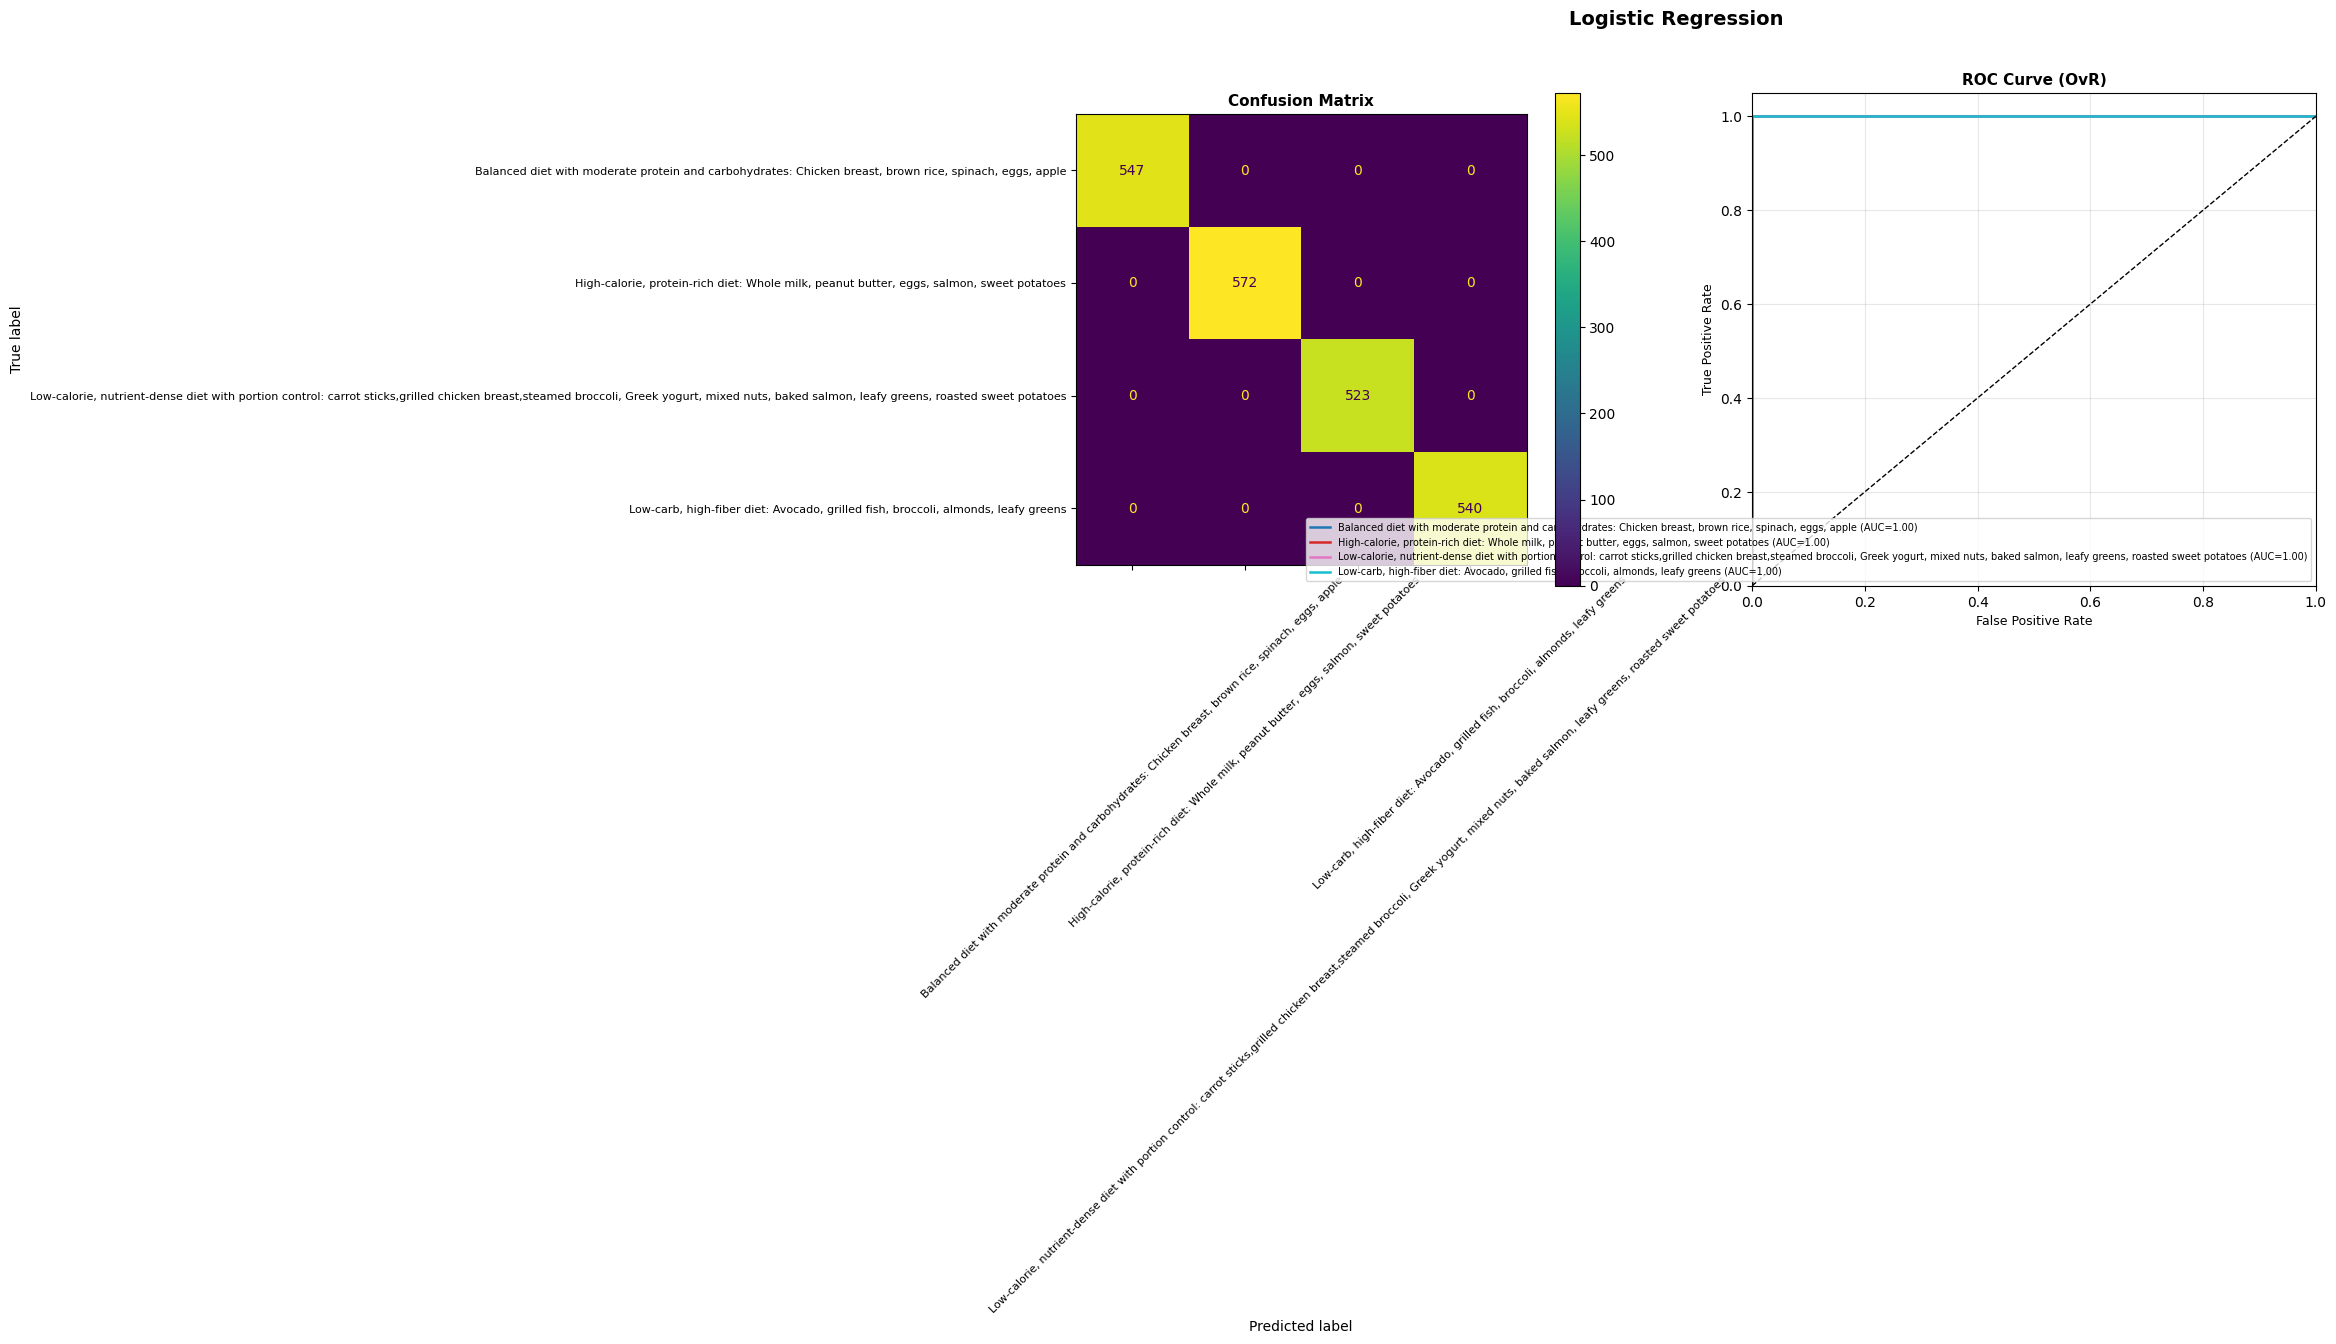

  KNN
  Accuracy: 1.0000
                                                                                                                                                                                            precision    recall  f1-score   support

                                                                                   Balanced diet with moderate protein and carbohydrates: Chicken breast, brown rice, spinach, eggs, apple       1.00      1.00      1.00       547
                                                                                                  High-calorie, protein-rich diet: Whole milk, peanut butter, eggs, salmon, sweet potatoes       1.00      1.00      1.00       572
Low-calorie, nutrient-dense diet with portion control: carrot sticks,grilled chicken breast,steamed broccoli, Greek yogurt, mixed nuts, baked salmon, leafy greens, roasted sweet potatoes       1.00      1.00      1.00       523
                                                              

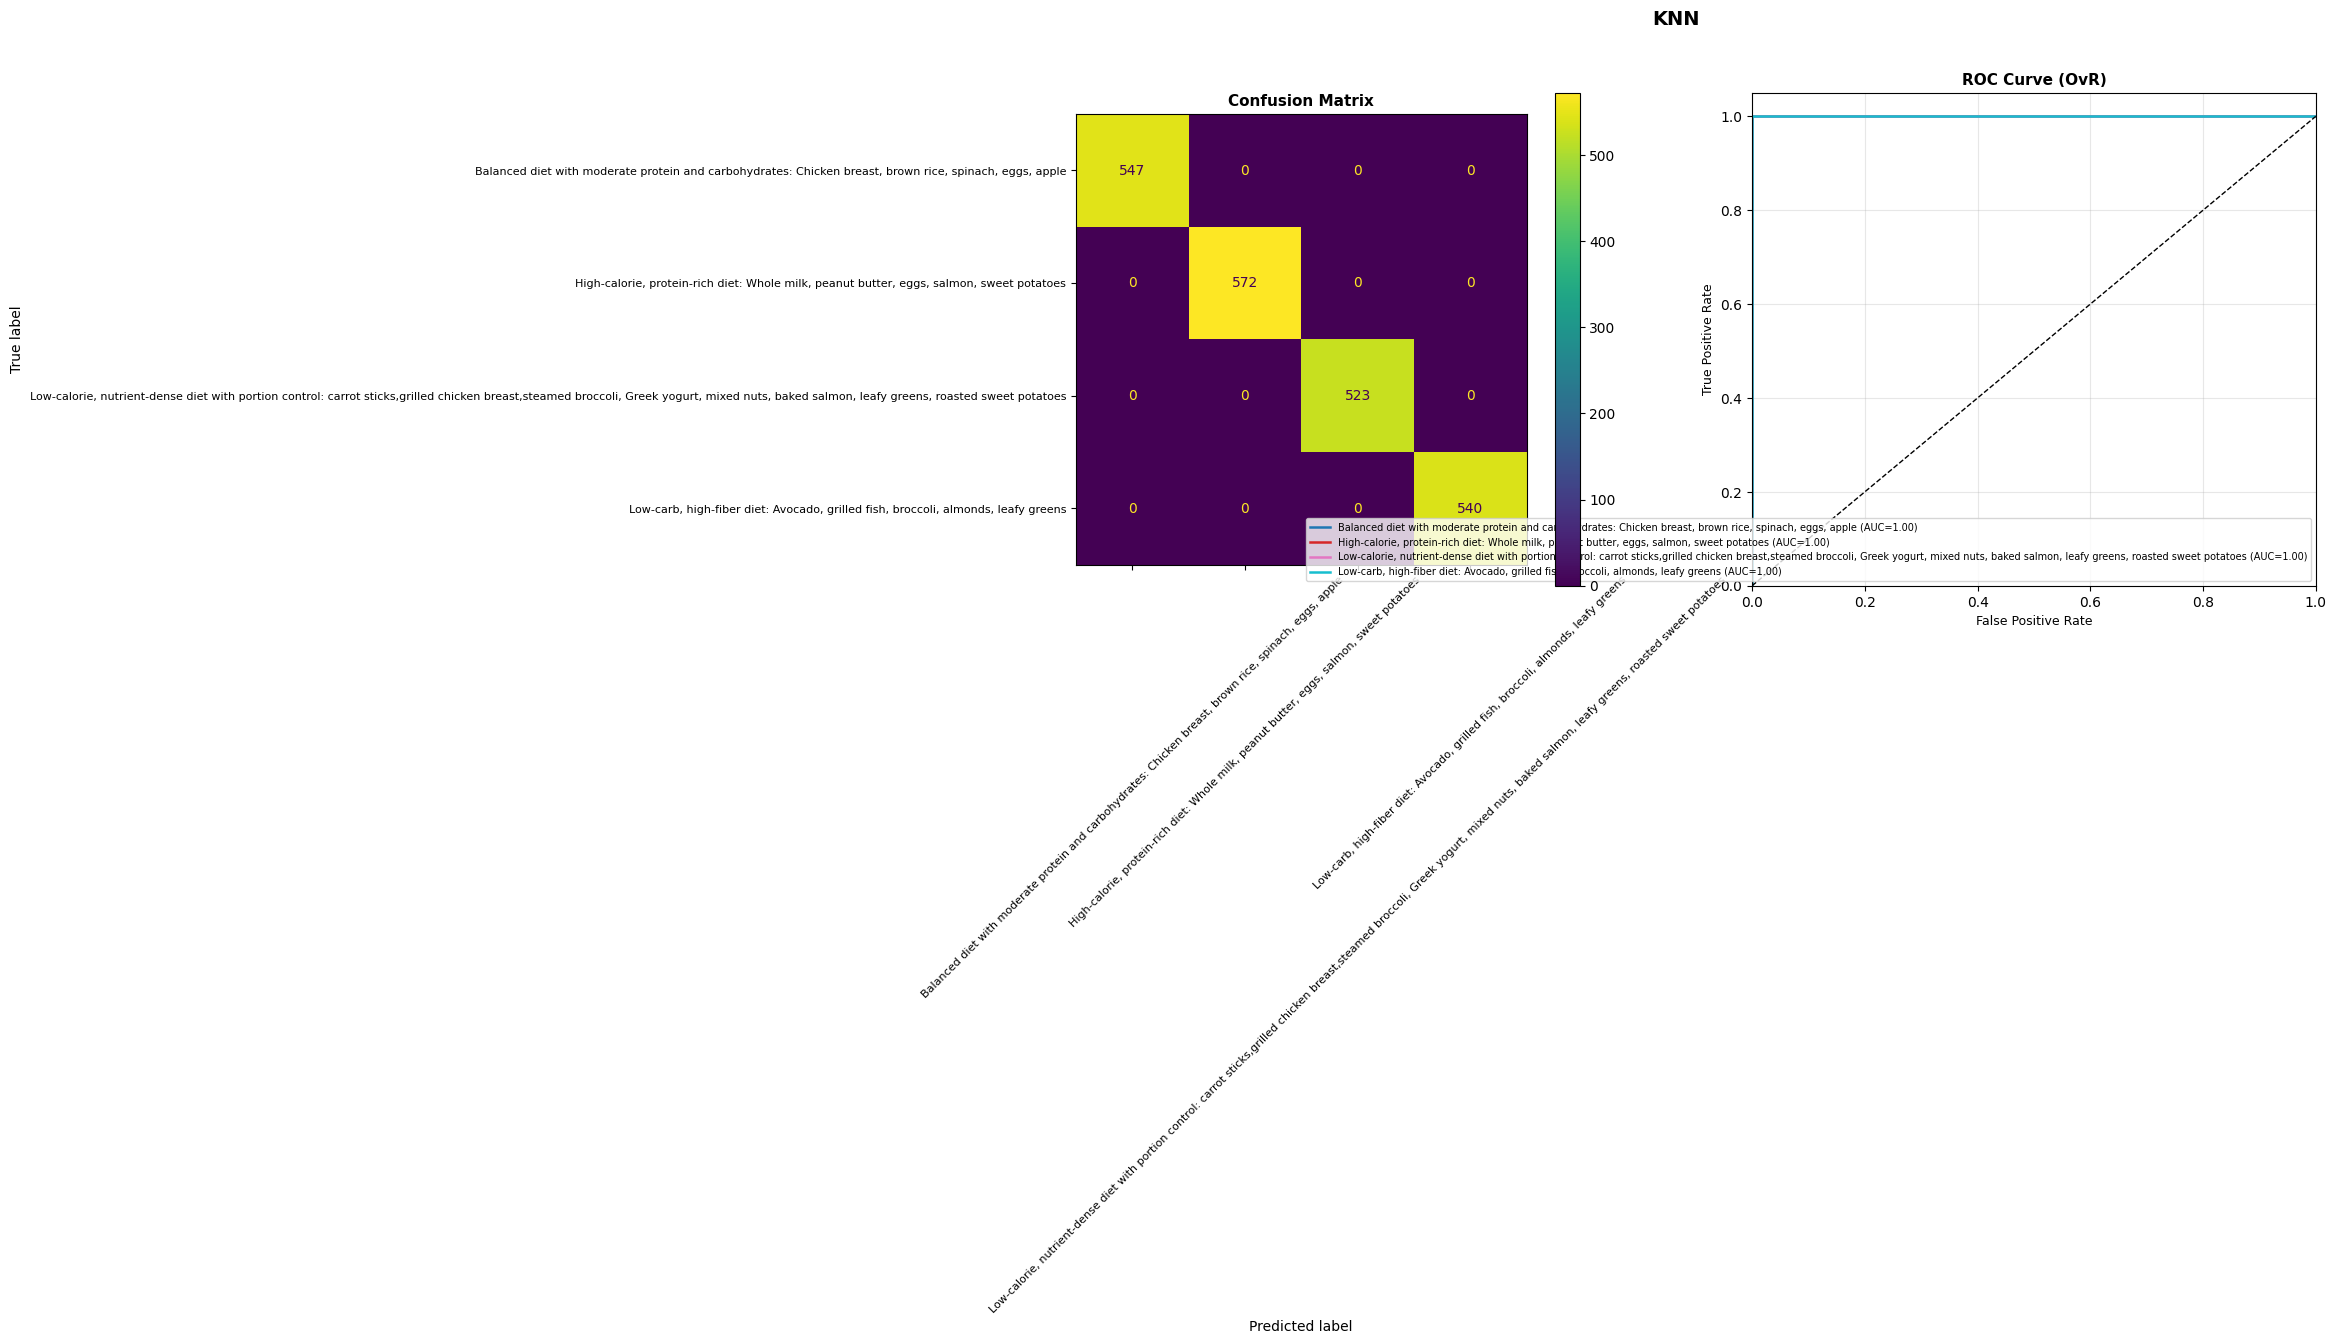

  Random Forest
  Accuracy: 1.0000
                                                                                                                                                                                            precision    recall  f1-score   support

                                                                                   Balanced diet with moderate protein and carbohydrates: Chicken breast, brown rice, spinach, eggs, apple       1.00      1.00      1.00       547
                                                                                                  High-calorie, protein-rich diet: Whole milk, peanut butter, eggs, salmon, sweet potatoes       1.00      1.00      1.00       572
Low-calorie, nutrient-dense diet with portion control: carrot sticks,grilled chicken breast,steamed broccoli, Greek yogurt, mixed nuts, baked salmon, leafy greens, roasted sweet potatoes       1.00      1.00      1.00       523
                                                    

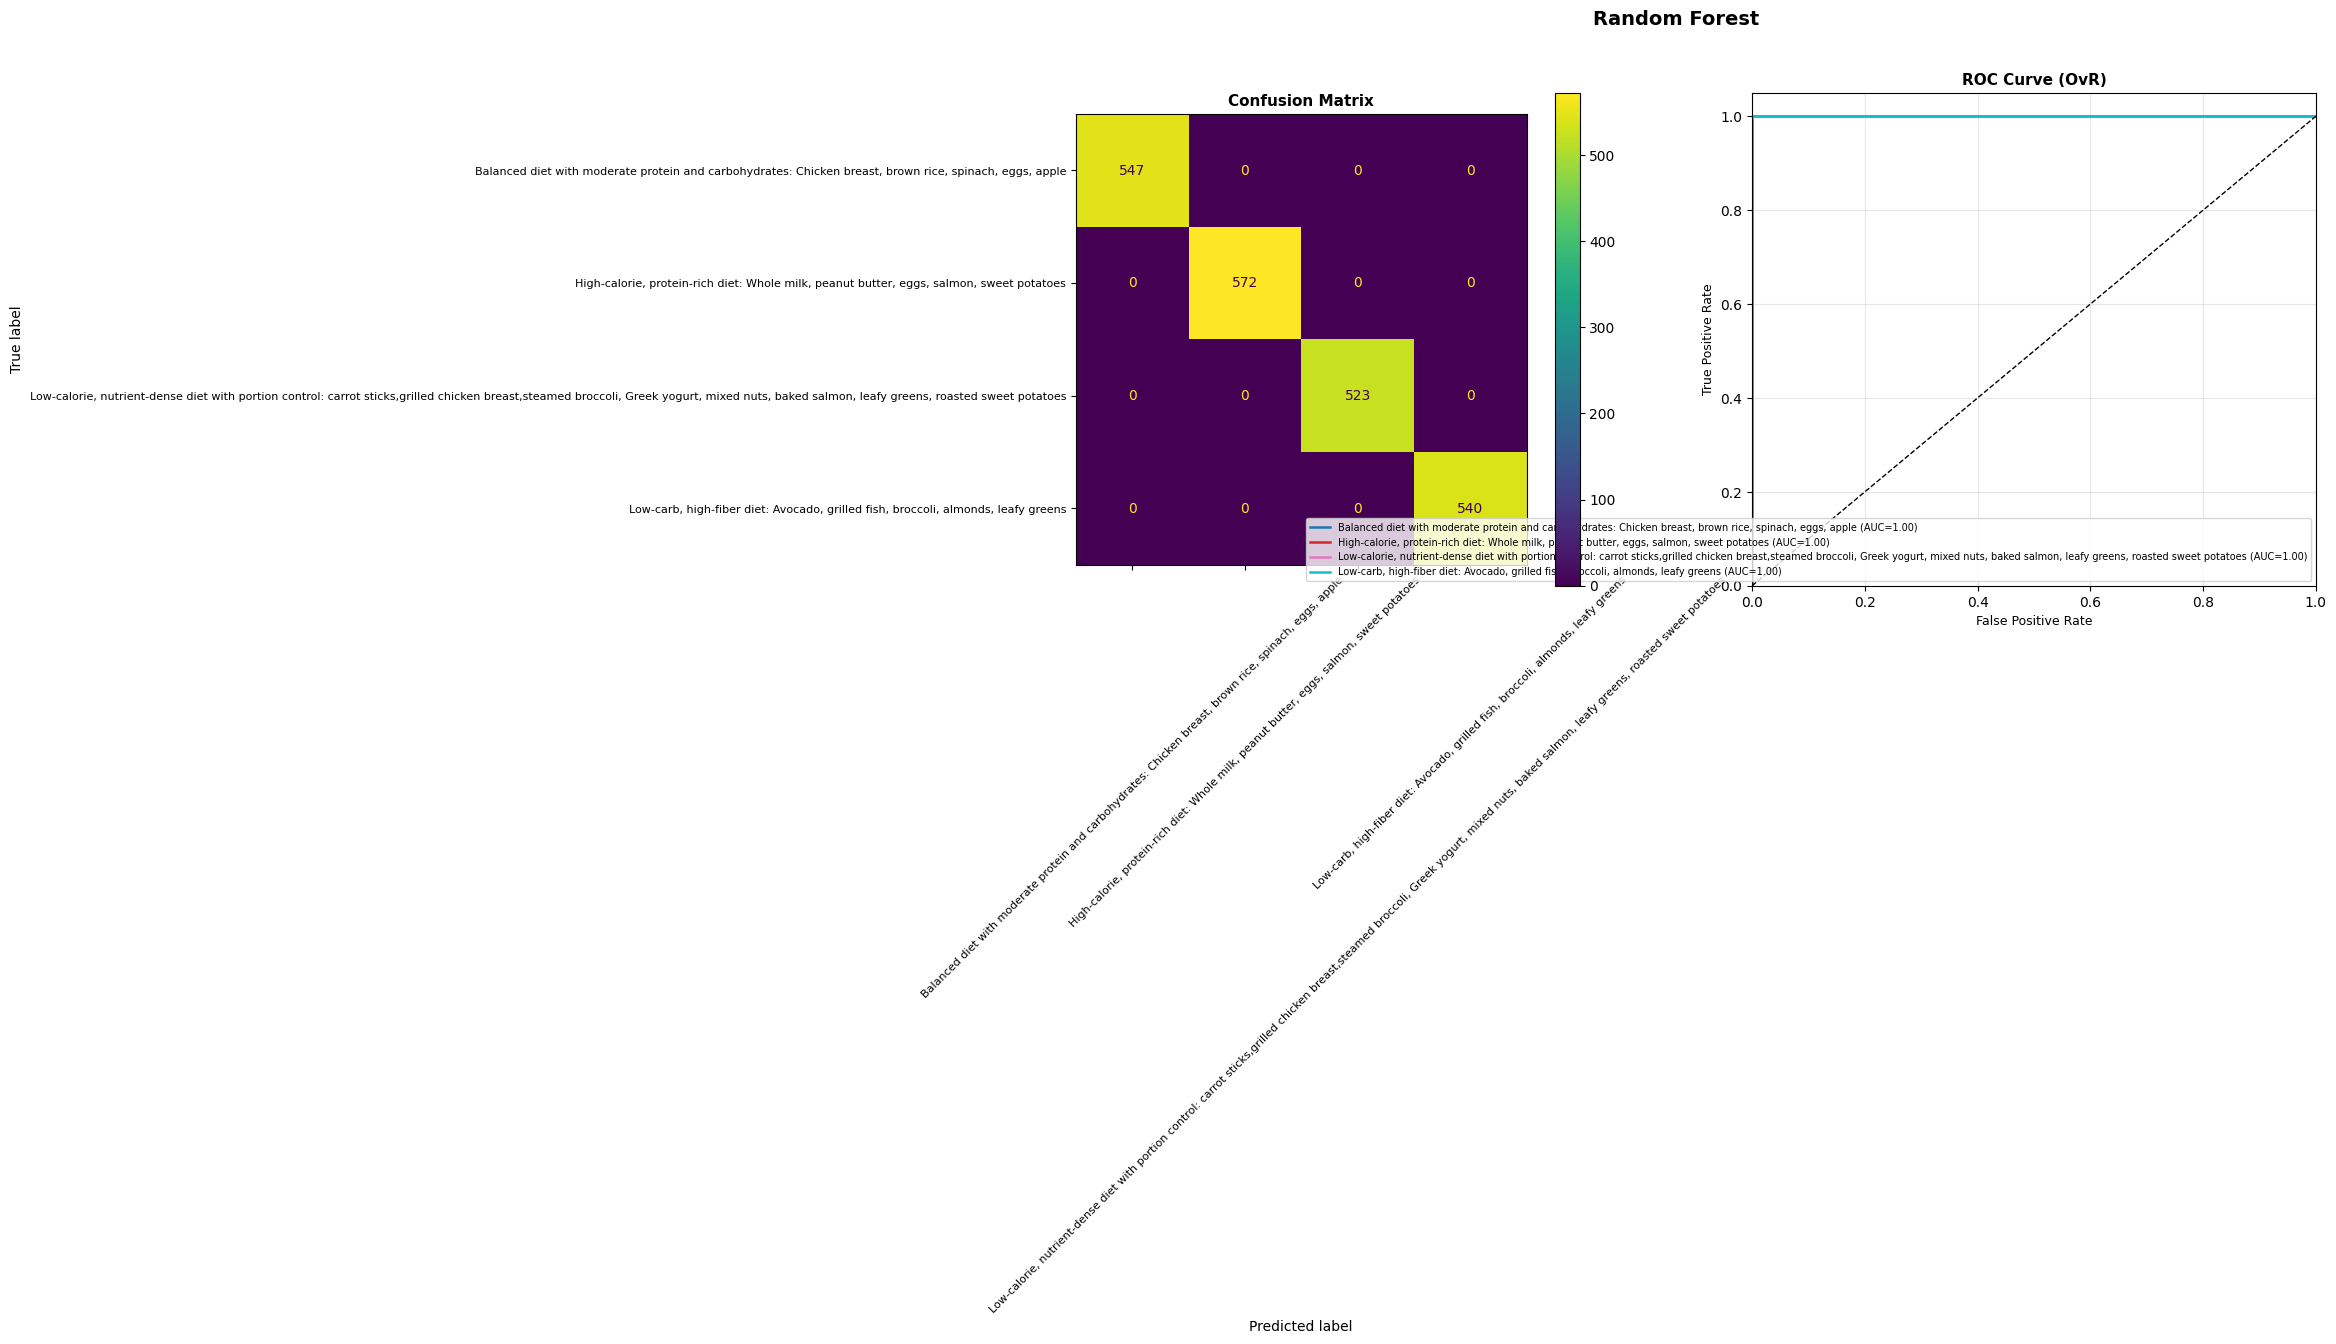

  XGBoost
  Accuracy: 1.0000
                                                                                                                                                                                            precision    recall  f1-score   support

                                                                                   Balanced diet with moderate protein and carbohydrates: Chicken breast, brown rice, spinach, eggs, apple       1.00      1.00      1.00       547
                                                                                                  High-calorie, protein-rich diet: Whole milk, peanut butter, eggs, salmon, sweet potatoes       1.00      1.00      1.00       572
Low-calorie, nutrient-dense diet with portion control: carrot sticks,grilled chicken breast,steamed broccoli, Greek yogurt, mixed nuts, baked salmon, leafy greens, roasted sweet potatoes       1.00      1.00      1.00       523
                                                          

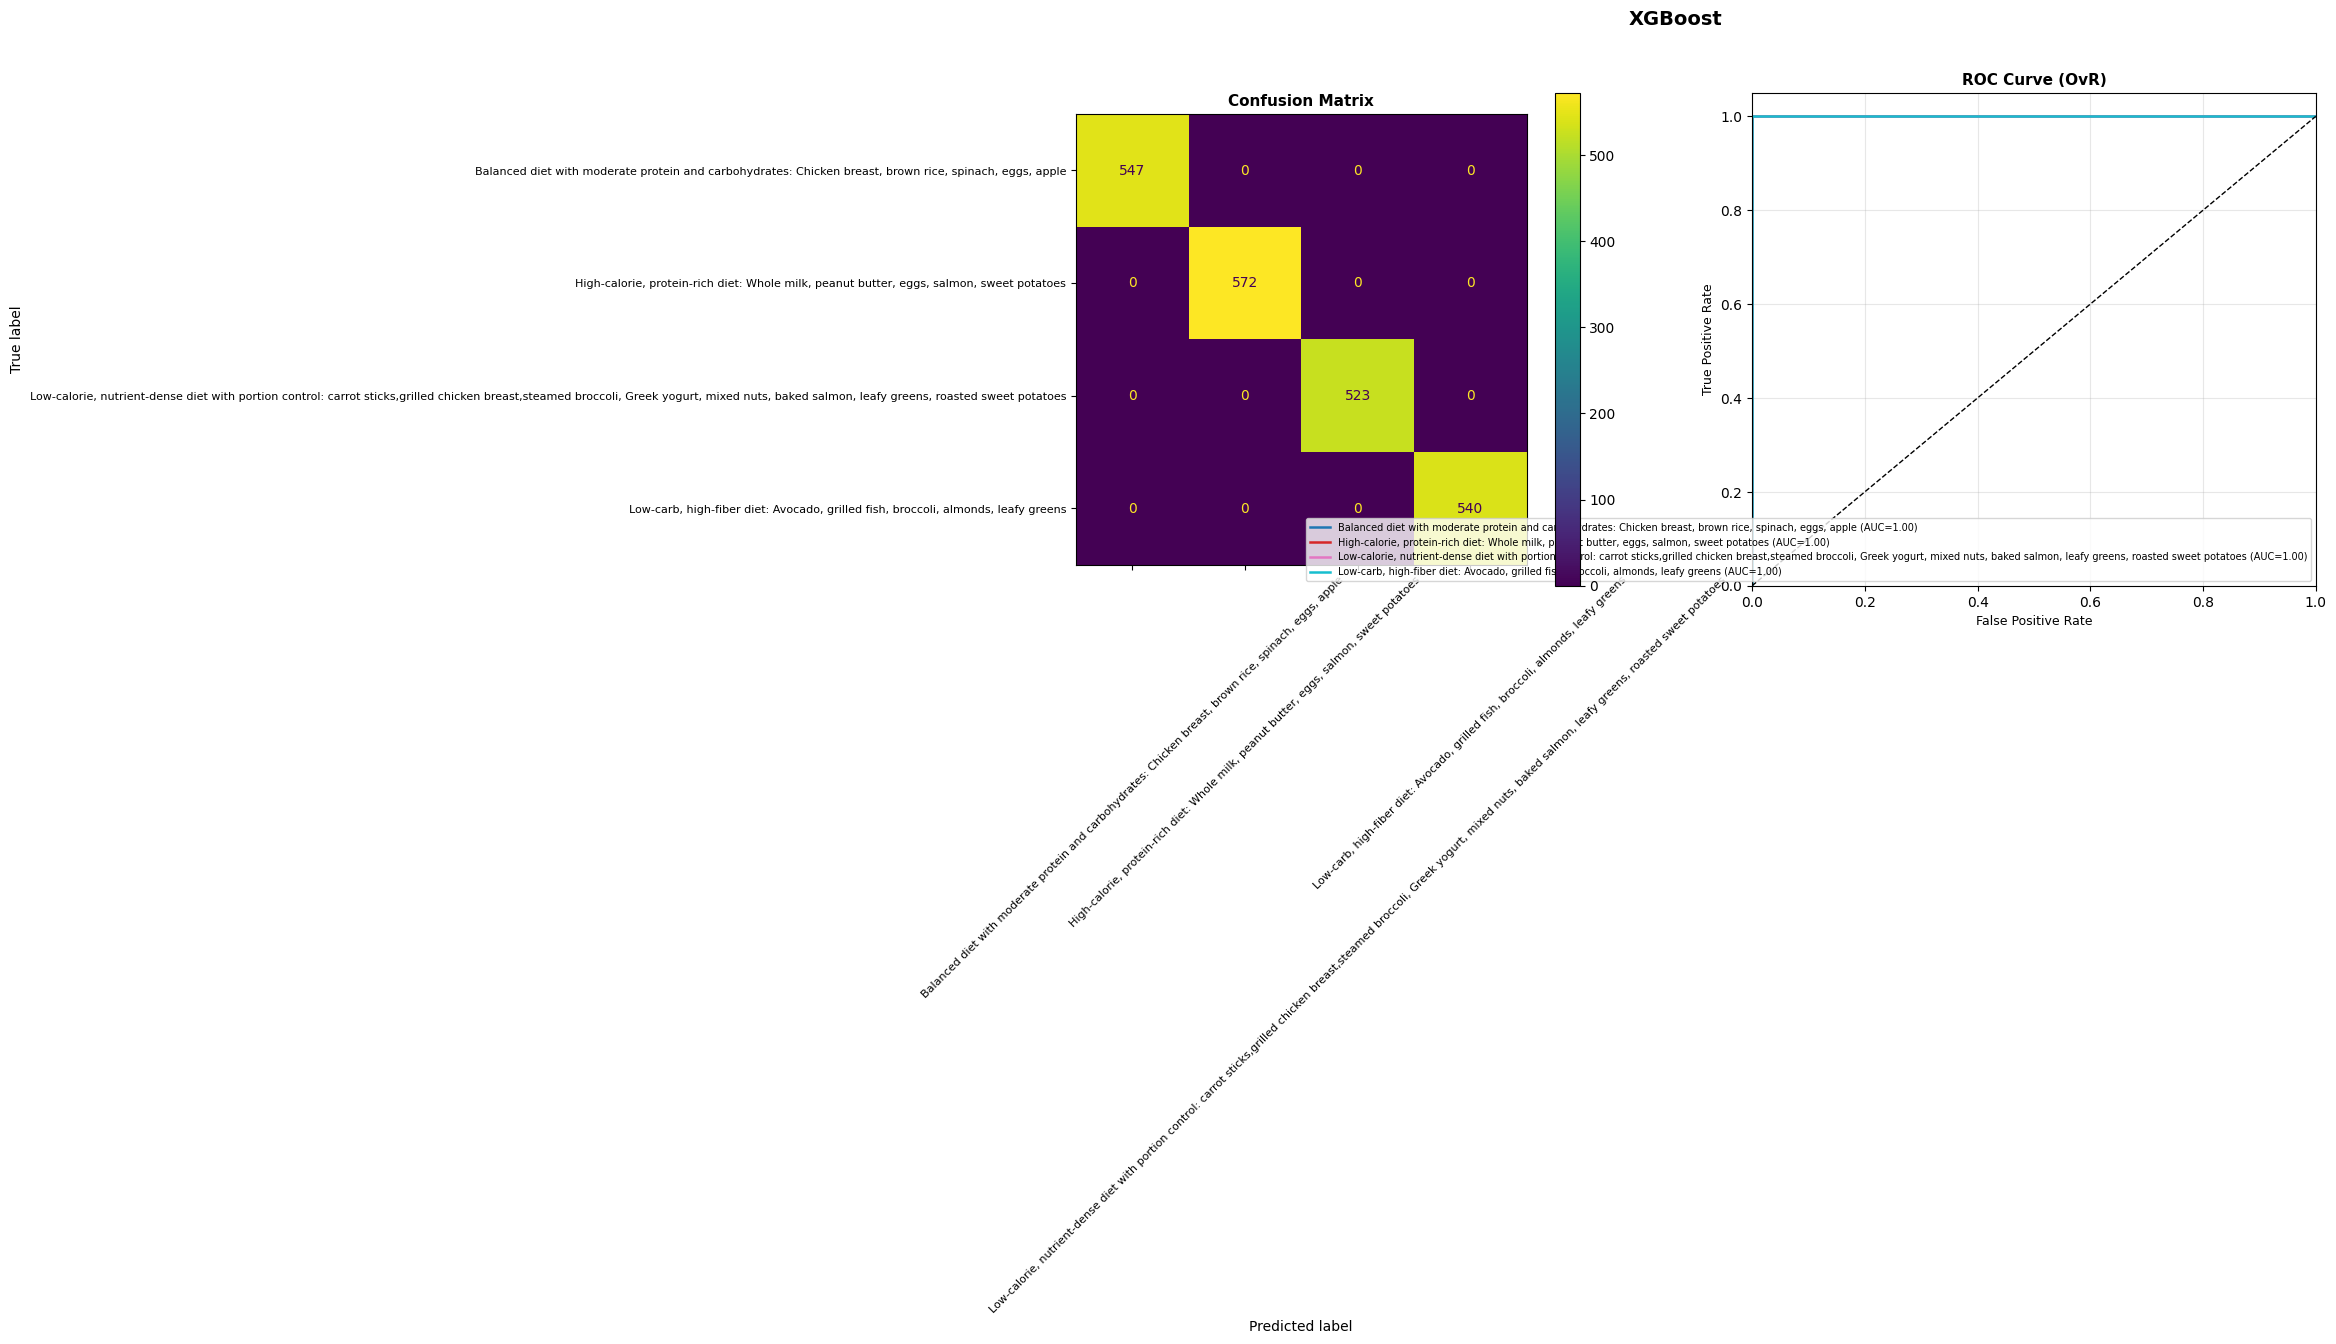

In [14]:
summary_rows = []
trained = {}

for name, model in models.items():
    print(f"  {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"  Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=meal_classes, zero_division=0))

    summary_rows.append({"Model": name, "Accuracy": round(acc, 4)})
    trained[name] = model

    n_cls    = len(meal_classes)
    fig_size = max(8, n_cls * 1.5)

    fig, axes = plt.subplots(1, 2, figsize=(fig_size * 2, fig_size * 0.8))
    fig.suptitle(name, fontsize=14, fontweight="bold", y=1.01)

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=meal_classes
    ).plot(ax=axes[0], colorbar=True, xticks_rotation=45)
    axes[0].set_title("Confusion Matrix", fontsize=11, fontweight="bold")
    axes[0].tick_params(axis="x", labelsize=8)
    axes[0].tick_params(axis="y", labelsize=8)

    plot_multiclass_roc(model, X_test, y_test, meal_classes, "ROC Curve (OvR)", axes[1])
    plt.show()

## 8. Model Accuracy Comparison

                     Accuracy
Model                        
Logistic Regression       1.0
KNN                       1.0
Random Forest             1.0
XGBoost                   1.0


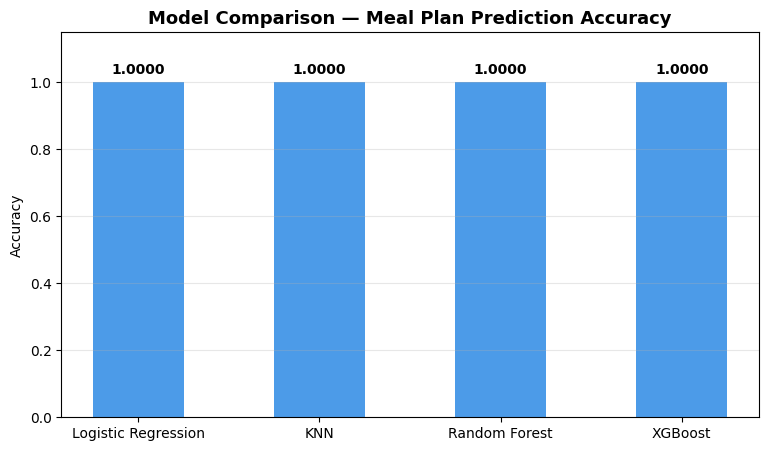

In [19]:
summary_df = pd.DataFrame(summary_rows).set_index("Model")
print(summary_df.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
colors = [ "#4C9BE8" for m in summary_df.index]
bars = ax.bar(summary_df.index, summary_df["Accuracy"], color=colors, width=0.5)

for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{h:.4f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, 1.15)
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison — Meal Plan Prediction Accuracy", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
plt.show()

## 9. Exporting Logistic Regression 

In [21]:
joblib.dump(trained["Logistic Regression"], os.path.join(OUTPUT_DIR, "logreg_model.pkl"))
joblib.dump(ohe,     os.path.join(OUTPUT_DIR, "onehot_encoder.pkl"))
joblib.dump(le_meal, os.path.join(OUTPUT_DIR, "label_encoder_meal.pkl"))

print("Exported:")

Exported:
